# Immune-cell composition across conditions (stacked 100% bars)

## Purpose
This notebook summarizes **immune cell-type composition** across treatment conditions (and days) using stacked bar plots normalized to 100% per condition. It is intended as a quick, publication-ready visualization of **relative cell-type proportions** (not absolute counts).

It also defines a helper function (`ct_table`) that can be used to assemble a long-format table of per-group cell-type abundances (useful for downstream statistical modeling).

## Inputs
**Primary input**
- `mel_cytokines_andata.h5ad` (AnnData), loaded via `scanpy.read_h5ad(...)`.

**AnnData requirements**
- `adata.obs` must contain:
  - `Condition` (e.g., `Pmel1`, `Pmel1.Il21`, `Pmel1.Il15`, `Pmel1.Il21.Il15`, `Mock`)
  - `cell_type` (cell-type annotation)
  - a day column named either `harvest_day` **or** `Harvest_Day`
  - an optional batch column named either `batch` **or** `tech_rep` (used only for excluding batches)
- `adata.uns["immune_obs_names"]` must exist and define the immune-cell subset (obs_names list/Index).
- `adata.uns["cell_type_colors"]` must exist (Scanpy convention), aligned to `adata.obs["cell_type"].cat.categories`.

## Outputs
- `stacked_celltype_day4.pdf`
- `stacked_celltype_day8.pdf`

(Outputs are written to the current notebook working directory unless you change the save paths.)

## Dependencies
- `scanpy`, `numpy`, `pandas`
- plotting: `matplotlib`, `seaborn` (seaborn not strictly required if you don’t use it elsewhere)
- Note: several geo/spatial imports appear in the imports cell but are not required for the stacked composition plot.

## Run order
Run cells top-to-bottom:
1) Imports
2) Load AnnData and subset to immune cells (`immune_obs_names`)
3) (Optional) sanity-check `adata`
4) Define helper functions (`ct_table`, `plot_celltype_stacked_100`)
5) Generate stacked 100% plots for day 4 and day 8 and save PDFs

## Notes / common pitfalls
- **Column naming:** this notebook supports both `harvest_day` and `Harvest_Day`. If neither exists, plotting will error.
- **Color mapping:** requires `adata.uns["cell_type_colors"]` and categorical `adata.obs["cell_type"]`.
- **Batch exclusions:** by default excludes batches `("58","33","32","9")` *if* a batch-like column is present.
- **Legend order:** `legend_order` is manually specified; update it to match your `cell_type` names.

In [ ]:
# mamba activate squidpy-voyagerpy_v1 
import scanpy as sc
import numpy as np
import os
import matplotlib.pyplot as plt

import pandas as pd

import alphashape as alphashape


/vf/users/kanferg/conda_v1/envs/squidpy-voyagerpy_v1/lib/python3.8/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


## Load input AnnData and subset to immune cells
This notebook uses `adata.uns["immune_obs_names"]` to subset the full dataset to immune cells only.
Update `pathout` to point to the folder containing `mel_cytokines_andata.h5ad`.

In [ ]:
# Large input files for this notebook are hosted on Zenodo; download and unpack the Zenodo bundle locally and set the base data path below to your local folder.
DATA_ROOT = "data_external/nguyenlab-il15act-dataset-v1"
pathout = os.path.join(DATA_ROOT, "01_processed_anndata")
adata_concat = sc.read_h5ad(os.path.join(pathout, "mel_cytokines_andata.h5ad"))
adata = adata_concat[adata_concat.uns["immune_obs_names"]].copy()

In [4]:
adata

AnnData object with n_obs × n_vars = 362350 × 2000
    obs: 'cell_id', 'punch_id', 'cell_type', 'cluster_spatialleiden', 'sample_id', 'mouse_id', 'tech_rep', 'Condition', 'harvest_day', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count'
    var: 'n_cells_by_counts'
    uns: 'HarmonyNigb', 'cellType_major_colors', 'cellType_scANvi_human_major_colors', 'cellType_scANvi_major_colors', 'cell_type_colors', 'immune_obs_names', 'leiden', 'log1p', 'neighbors', 'overcluster_colors', 'pca', 'spatial_neighbors', 'spatialleiden_colors', 'umap'
    obsm: 'Unintegrated_umap', 'X_pca', 'X_pca_Harmony', 'X_umap', 'spatial', 'spatial_umap'
    varm: 'PCs'
    layers: 'counts', 'log', 'scvi_normalized'
    obsp: 'HarmonyNigb_connectivities', 'HarmonyNigb_distances', 'connectivities', 'distances', 'spatial_connectivities', 'spatial_distances'

## Load input AnnData and subset to immune cells
This notebook uses `adata.uns["immune_obs_names"]` to subset the full dataset to immune cells only.
Update `pathout` to point to the folder containing `mel_cytokines_andata.h5ad`.

In [ ]:
def ct_table(adata_concat, ct_key='cell_type'):
    '''
    Generates a dataframe for cell type abundance analysis across conditions and batches.

    This function filters the input AnnData object for specific batches and conditions,
    then calculates the abundance of a specified cell type relative to the total number
    of cells per treatment-batch group. Pseudo-counts are added to avoid zero values.

    Parameters
    ----------
    adata_concat : AnnData
        The input AnnData object containing single-cell data.
    ct_key : str, default 'cell_type'
        The specific cell type name (found in adata.obs['cell_type']) to analyze.
        
    Returns
    -------
    pd.DataFrame
        A DataFrame with columns:
        - 'treatment_batch': Combined condition, day, and batch.
        - 'n_cells': Total cells in the group.
        - 'treatment': Combined condition and day.
        - 'n_cells_ct': Count of the specific cell type (with pseudo-count +1).
        - 'batch': Batch identifier.
        - 'celltype': The name of the cell type analyzed.
    '''
    adata_concat.obs['Condition'] = adata_concat.obs['Condition'].astype(str)
    batch_l = ['58','33','32','9']
    adata_concat = adata_concat[~adata_concat.obs['batch'].isin(batch_l)]
    adata_concat_rest = adata_concat[adata_concat.obs['Condition'].isin(['Pmel1','Pmel1.Il21', 'Pmel1.Il15', 'Pmel1.Il21.Il15', 'Mock'])].copy() 
    df = adata_concat_rest.obs.copy()
    def catTostring(colList):
        for col in colList:
            df[col] = df[col].astype(str)
    colList = ['cell_type','batch','Harvest_Day', 'Condition']
    catTostring(colList)
    df['treatment'] = df['Condition'] + '_' + df['Harvest_Day']
    df.loc[df['cell_type']==ct_key].groupby('treatment').size()
    df['treatment_batch'] = df['Condition'] + '_' + df['Harvest_Day'] + '_' + df['batch']
    df_plt = pd.DataFrame({'treatment_batch':df.groupby('treatment_batch').size().index.values, 'n_cells':df.groupby('treatment_batch').size(),"treatment":df.groupby(['treatment_batch','treatment'], as_index=False)['treatment'].size()['treatment'].values}).reset_index(drop=True)
    df_plt['n_cells_ct'] = df.loc[df['cell_type']==ct_key].groupby('treatment_batch').size().reset_index(drop=True)
    cond_order = ['Mock','Pmel1', 'Pmel1.Il21', 'Pmel1.Il15', 'Pmel1.Il21.Il15']
    day_order =['4','8']
    treatment_order = [f"{c}_{d}" for c in cond_order for d in day_order]
    df_plt["treatment"] = pd.Categorical(
        df_plt["treatment"],
        categories=treatment_order,
        ordered=True,
    )
    df_plt['batch'] = [re.sub(r'.*_', '', b) for b in df_plt['treatment_batch']]
    # add psudo counts to avoid zero counts
    df_plt['n_cells_ct'] = df_plt['n_cells_ct'] + 1
    df_plt['celltype'] = ct_key
    return df_plt

In [6]:
def _pick_col(adata, candidates):
    for c in candidates:
        if c in adata.obs.columns:
            return c
    raise KeyError(f"None of these columns were found in adata.obs: {candidates}")

def _get_ct_color_map(adata, ct_key="cell_type", colors_uns_key="cell_type_colors"):
    """
    Returns dict: {cell_type: color} using adata.uns[colors_uns_key] aligned to
    adata.obs[ct_key].cat.categories (Scanpy convention).
    """
    if colors_uns_key not in adata.uns:
        raise KeyError(f"'{colors_uns_key}' not found in adata.uns. Available keys: {list(adata.uns.keys())[:20]} ...")

    ct = adata.obs[ct_key]
    if not pd.api.types.is_categorical_dtype(ct):
        ct = ct.astype("category")

    cats = list(ct.cat.categories)
    cols = list(adata.uns[colors_uns_key])

    if len(cols) < len(cats):
        raise ValueError(
            f"adata.uns['{colors_uns_key}'] has {len(cols)} colors but {len(cats)} categories in obs['{ct_key}']."
        )

    return {k: cols[i] for i, k in enumerate(cats)}

def plot_celltype_stacked_100(
    adata,
    legend_order,
    ct_key="cell_type",
    condition_key="Condition",
    day_key_candidates=("harvest_day", "Harvest_Day"),
    batch_key_candidates=("batch", "tech_rep"),
    colors_uns_key="cell_type_colors",
    conditions_keep=("Pmel1", "Pmel1.Il21", "Pmel1.Il15", "Pmel1.Il21.Il15", "Mock"),
    exclude_batches=("58","33","32","9"),
    make_separate_figs=True,
):
    """
    Stacked bars normalized to 100% per Condition, split by day (two panels: day 4 and day 8).
    Uses colors from adata.uns[colors_uns_key] (Scanpy convention).
    """
    day_key = _pick_col(adata, list(day_key_candidates))
    # batch key is optional; only used for excluding batches if present
    batch_key = None
    for c in batch_key_candidates:
        if c in adata.obs.columns:
            batch_key = c
            break

    # copy obs only
    df = adata.obs[[ct_key, condition_key, day_key] + ([batch_key] if batch_key else [])].copy()
    df[condition_key] = df[condition_key].astype(str)
    df[day_key] = df[day_key].astype(str)
    df[ct_key] = df[ct_key].astype(str)

    # filter conditions
    if conditions_keep is not None:
        df = df[df[condition_key].isin(list(conditions_keep))].copy()

    # exclude specific batches if possible
    if batch_key is not None and exclude_batches:
        df = df[~df[batch_key].astype(str).isin(list(exclude_batches))].copy()

    # enforce x-order (Condition)
    cond_order = list(conditions_keep) if conditions_keep is not None else sorted(df[condition_key].unique())
    df[condition_key] = pd.Categorical(df[condition_key], categories=cond_order, ordered=True)

    # color map from uns
    ct_color_map = _get_ct_color_map(adata, ct_key=ct_key, colors_uns_key=colors_uns_key)

    # final legend order (only keep those that exist)
    present_cts = set(df[ct_key].unique())
    legend_order_present = [ct for ct in legend_order if ct in present_cts]

    # days to plot (prefer 4 then 8 if present)
    day_vals = list(pd.unique(df[day_key]))
    preferred_days = [d for d in ["4", "8"] if d in day_vals]
    other_days = [d for d in day_vals if d not in preferred_days]
    days_to_plot = preferred_days + sorted(other_days)

    # publication-ish styling
    plt.rcParams.update({
        "font.size": 7,
        "axes.titlesize": 8,
        "axes.labelsize": 7,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "legend.fontsize": 7,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    })

    def _make_panel(ax, d):
        ddf = df[df[day_key] == d].copy()

        # counts per (Condition, cell_type)
        tab = pd.crosstab(ddf[condition_key], ddf[ct_key])  # rows=Condition, cols=cell_type
        tab = tab.reindex(cond_order)  # enforce x order

        # keep only legend-ordered columns (and only those present)
        tab = tab.reindex(columns=legend_order_present, fill_value=0)

        # normalize to 100%
        denom = tab.sum(axis=1).replace(0, np.nan)
        frac = (tab.div(denom, axis=0) * 100).fillna(0)

        x = np.arange(frac.shape[0])
        bottom = np.zeros(frac.shape[0], dtype=float)

        for ct in frac.columns:
            ax.bar(
                x,
                frac[ct].values,
                bottom=bottom,
                width=0.85,
                color=ct_color_map.get(ct, "#999999"),
                edgecolor="white",
                linewidth=0.3,
                label=ct,
            )
            bottom += frac[ct].values

        ax.set_ylim(0, 100)
        ax.set_ylabel("Cell type (%)")
        ax.set_title(f"Day {d}")
        ax.set_xticks(x)
        ax.set_xticklabels([str(c) for c in frac.index], rotation=35, ha="right")
        ax.grid(axis="y", linewidth=0.3, alpha=0.3)
        ax.set_axisbelow(True)
        return ax

    if make_separate_figs:
        figs = []
        for d in days_to_plot[:2]:  # requested day 4 and day 8; will plot up to first two days found
            fig, ax = plt.subplots(figsize=(3.35, 2.6))  # single-column friendly
            _make_panel(ax, d)

            # legend outside
            handles, labels = ax.get_legend_handles_labels()
            ax.legend(
                handles, labels,
                title=None,
                loc="center left",
                bbox_to_anchor=(1.02, 0.5),
                frameon=False,
            )

            fig.tight_layout()
            figs.append(fig)
        return figs

    else:
        # two panels in one figure (day 4 + day 8)
        n = min(2, len(days_to_plot))
        fig, axes = plt.subplots(1, n, figsize=(6.8, 2.6), sharey=True)  # double-column width-ish
        if n == 1:
            axes = [axes]
        for ax, d in zip(axes, days_to_plot[:n]):
            _make_panel(ax, d)

        handles, labels = axes[-1].get_legend_handles_labels()
        fig.legend(
            handles, labels,
            loc="center left",
            bbox_to_anchor=(1.01, 0.5),
            frameon=False,
        )
        fig.tight_layout()
        return fig

## Plot: stacked 100% cell-type composition per condition (split by day)
`plot_celltype_stacked_100(...)` computes a contingency table of cell types per condition, normalizes each condition to 100%,
and plots stacked bars using `adata.uns["cell_type_colors"]` for consistent coloring.

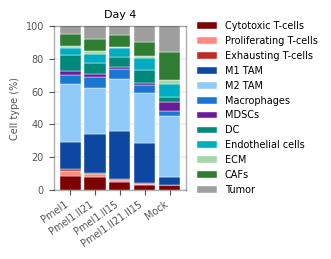

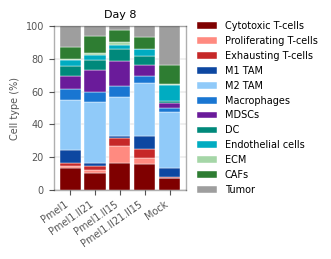

In [8]:
legend_order = [
    "Cytotoxic T-cells",
    "Proliferating T-cells",
    "Exhausting T-cells",
    "M1 TAM",
    "M2 TAM",
    "Macrophages",
    "MDSCs",
    "DC",
    "Endothelial cells",
    "ECM",
    "CAFs",
    "Tumor",
]

# make two separate figures: day 4 and day 8 (if present)
figs = plot_celltype_stacked_100(
    adata,
    legend_order=legend_order,
    ct_key="cell_type",
    condition_key="Condition",
    colors_uns_key="cell_type_colors",   # uses adata.uns['cell_type_colors']
    make_separate_figs=True,
)

# Save (optional)
figs[0].savefig("stacked_celltype_day4.pdf", bbox_inches="tight")
figs[1].savefig("stacked_celltype_day8.pdf", bbox_inches="tight")
plt.show()